In [31]:
import pandas as pd
import numpy as np
import re
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
from sklearn.utils import resample
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

In [32]:
pip install deep-translator

In [33]:
# ================================================================
# 🧹 STEP 1: Load and Clean Dataset
# ================================================================
print("📥 Loading dataset...")
df = pd.read_csv('cleaned_reviews.csv')
df = df.dropna(subset=['review_text'])
print("✅ Loaded dataset:", df.shape)

# --- Clean text function ---
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df['review_text'] = df['review_text'].apply(clean_text)

# --- Remove unrealistic or dummy text (like lorem ipsum) ---
df = df[~df['review_text'].str.contains("doloribus|ipsum|perspiciatis|lorem", case=False)]

📥 Loading dataset...
✅ Loaded dataset: (2418, 16)


In [34]:
# ================================================================
# 🌍 STEP 2: Translate Non-English Reviews (with fallback)
# ================================================================
try:
    from deep_translator import GoogleTranslator

    def translate_to_english(text):
        try:
            return GoogleTranslator(source='auto', target='en').translate(text)
        except:
            return text

    print("🌐 Translating non-English reviews to English...")
    df['review_text'] = df['review_text'].apply(translate_to_english)
    print("✅ Translation complete.")
except Exception as e:
    print("⚠️ Translator not available, continuing without translation:", e)

🌐 Translating non-English reviews to English...
✅ Translation complete.


In [35]:
# ================================================================
# 🏷️ STEP 3: Relabel Sentiment Based on Ratings
# ================================================================
def rating_to_sentiment(r):
    if r <= 2.0: return "positive"
    elif r >= 4.0: return "negative"
    else: return "neutral"

df['sentiment'] = df['rating'].apply(rating_to_sentiment)

In [36]:
# ================================================================
# ✂️ STEP 4: Remove Short or Empty Reviews
# ================================================================
df['review_length'] = df['review_text'].apply(lambda x: len(str(x).split()))
df = df[df['review_length'] > 3]

print("✅ Dataset cleaned and filtered:", df.shape)

✅ Dataset cleaned and filtered: (2176, 17)


In [37]:
# ================================================================
# ⚖️ STEP 5: Balance Dataset
# ================================================================
neutral = df[df['sentiment'] == 'neutral']
positive = df[df['sentiment'] == 'positive']
negative = df[df['sentiment'] == 'negative']

positive_upsampled = resample(positive, replace=True, n_samples=len(neutral), random_state=42)
negative_upsampled = resample(negative, replace=True, n_samples=len(neutral), random_state=42)

df_balanced = pd.concat([neutral, positive_upsampled, negative_upsampled])
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

print("\n✅ Balanced sentiment distribution:")
print(df_balanced['sentiment'].value_counts())


✅ Balanced sentiment distribution:
sentiment
negative    1066
neutral     1066
positive    1066
Name: count, dtype: int64


In [38]:
# ================================================================
# 🧩 STEP 6: Encode and Split Data
# ================================================================
sentiment_to_id = {"negative": 0, "neutral": 1, "positive": 2}
id_to_sentiment = {v: k for k, v in sentiment_to_id.items()}

df_balanced['label'] = df_balanced['sentiment'].map(sentiment_to_id)

X_train, X_test, y_train, y_test = train_test_split(
    df_balanced['review_text'],
    df_balanced['label'],
    test_size=0.2,
    random_state=42,
    stratify=df_balanced['label']
)

print("\n📊 Train size:", len(X_train), " | Test size:", len(X_test))


📊 Train size: 2558  | Test size: 640


In [39]:
# ================================================================
# 🔠 STEP 7: TF-IDF Vectorization
# ================================================================
print("\n🔠 Creating TF-IDF features...")
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2), stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)
print("✅ TF-IDF features ready. Shape:", X_train_tfidf.shape)


🔠 Creating TF-IDF features...
✅ TF-IDF features ready. Shape: (2558, 3439)


In [40]:
# ================================================================
# 🚀 STEP 8: Train and Tune Logistic Regression
# ================================================================
print("\n🚀 Training Logistic Regression model with tuning...")
log_reg = LogisticRegression(
    multi_class='multinomial',
    solver='saga',
    max_iter=500,
    random_state=42
)

param_grid = {
    'C': [0.1, 0.5, 1, 2, 5],
    'penalty': ['l2', 'l1']
}

grid_search = GridSearchCV(
    estimator=log_reg,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=3,
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train_tfidf, y_train)
best_model = grid_search.best_estimator_
print("\n✅ Best Parameters:", grid_search.best_params_)


🚀 Training Logistic Regression model with tuning...
Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



✅ Best Parameters: {'C': 5, 'penalty': 'l2'}


In [41]:
# ================================================================
# 📈 STEP 9: Evaluate Model
# ================================================================
y_pred = best_model.predict(X_test_tfidf)

acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average='weighted', zero_division=0)

print("\n📊 Model Performance:")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")


📊 Model Performance:
Accuracy  : 0.4188
Precision : 0.4255
Recall    : 0.4188
F1-score  : 0.4177


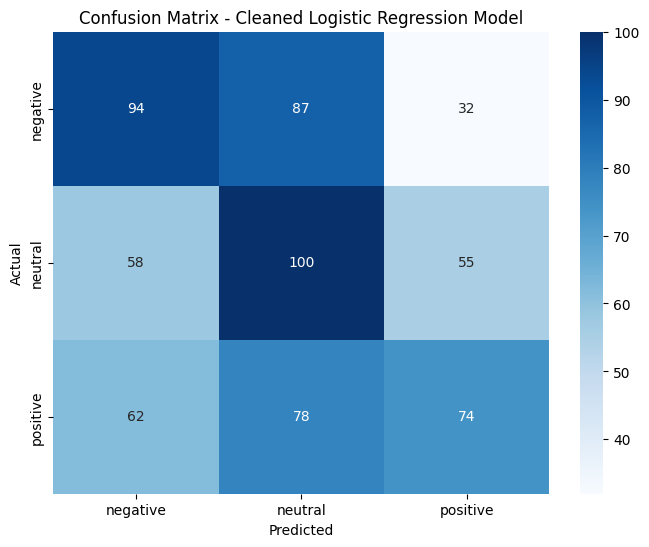

In [42]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=sentiment_to_id.keys(), yticklabels=sentiment_to_id.keys())
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Cleaned Logistic Regression Model')
plt.show()

In [43]:
# ================================================================
# 💬 STEP 10: Test Predictions
# ================================================================
def predict_sentiment(review):
    review_clean = clean_text(review)
    review_tfidf = tfidf.transform([review_clean])
    pred_label = best_model.predict(review_tfidf)[0]
    return id_to_sentiment[pred_label]

test_reviews = [
    "This app is absolutely fantastic, I use it every day!",
    "Worst experience ever. Crashes all the time.",
    "It’s okay, nothing special.",
    "Really love the new update!",
    "This app is terrible, please fix it soon."
]

print("\n🔍 Sample Predictions:")
for r in test_reviews:
    print(f"📝 {r}")
    print(f"→ Predicted Sentiment: {predict_sentiment(r).upper()}\n")

# ================================================================
# 💾 STEP 11: Save Model
# ================================================================
joblib.dump(best_model, "logreg_cleaned_sentiment_model.pkl")
joblib.dump(tfidf, "tfidf_vectorizer_cleaned.pkl")
print("💾 Model and TF-IDF vectorizer saved successfully!")



🔍 Sample Predictions:
📝 This app is absolutely fantastic, I use it every day!
→ Predicted Sentiment: POSITIVE

📝 Worst experience ever. Crashes all the time.
→ Predicted Sentiment: NEGATIVE

📝 It’s okay, nothing special.
→ Predicted Sentiment: NEUTRAL

📝 Really love the new update!
→ Predicted Sentiment: NEUTRAL

📝 This app is terrible, please fix it soon.
→ Predicted Sentiment: NEUTRAL

💾 Model and TF-IDF vectorizer saved successfully!
